In [ ]:
import os
import glob
import random
from pathlib import Path
import numpy as np
from scipy.stats import kruskal
import pandas as pd
import h5py
import anndata
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import openslide
from skimage.measure import regionprops_table
%matplotlib inline
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.colors import LinearSegmentedColormap
import umap
import scanpy as sc
import anndata
import leidenalg

import sys
sys.path.append('/scratch/users/k21066795/NBT-phenotyping')
from utils_pheno import * 

import warnings
warnings.filterwarnings("ignore")

In [2]:
basedir = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS'
save_prefix = f"{basedir}/NBTs_phenotypes03"
os.listdir(save_prefix)

['umap',
 'nuclei_quantification',
 'heatmap',
 'NBT-Classifier_annotation',
 'patches_examples',
 'Clustree',
 'adata']

# clean NBTs patch dataset 

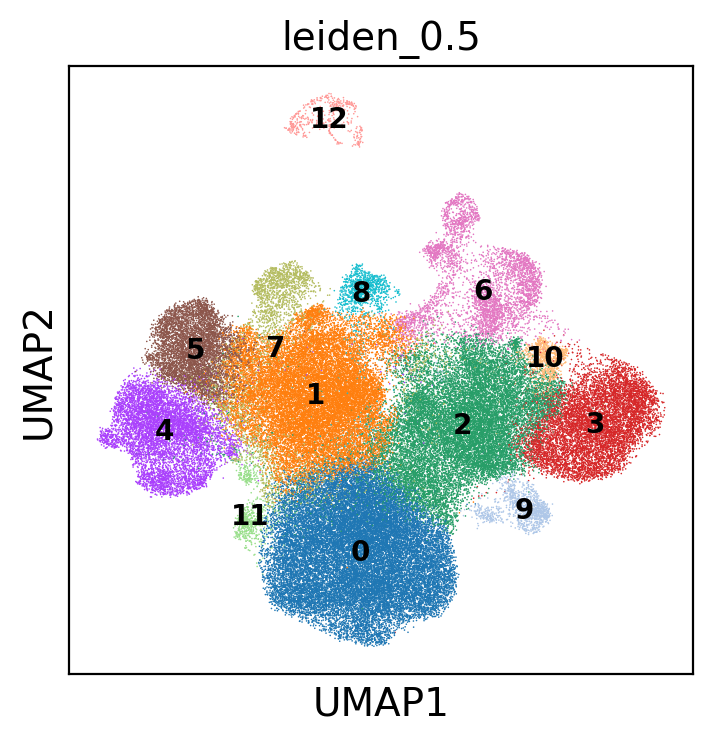

In [9]:
# aggregate all patches derived from NBTs (N: breast cancer patients; N_RM: reduction mammoplasty; N_RRM: risk-reducing mastectomy)
df_comb = pd.read_csv(f"{basedir}/FoundationModel_features01/NBTs_noSampling_combined_dataset.csv")
df_sampled = df_comb.groupby('patient_id').apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42)).reset_index(drop=True)

# initial Leiden clustering
n_neighbors = 15
resolution = 0.5
groupby = f"leiden_{resolution}"
adata = get_adata(df_sampled)
sc.tl.leiden(adata, resolution=resolution, key_added=groupby, neighbors_key = neighbors_key)
sc.tl.paga(adata, groups=groupby, neighbors_key=neighbors_key)
sc.pl.paga(adata, color=[groupby, 'source', 'cohort'], layout='fr', random_state=0, 
           threshold=0.29, node_size_scale=8, node_size_power=0.5, edge_width_scale=.05, fontsize=10, 
           fontoutline=2, cmap="Set1",frameon=False, show=False)
sc.tl.umap(adata, init_pos="paga", neighbors_key=neighbors_key)
sc.pl.umap(adata, color=groupby, legend_fontsize=10, legend_loc='on data', save=f'/{model_stain}_{groupby}')

In [ ]:
# remove artifacts
for i, cluster_id in enumerate(np.unique(adata_normal.obs[groupby])):
    plot_cluster_examples(adata_normal, groupby, cluster_id, sampled_number=5, grid_size=[1, 5], figsize=(12, 2), fontsize=8, save_dir=None, save_patches=False)

exclude_groups = ["5", "7", "8", "9", "10", "11"] 
clean_df = adata_normal.obs[~adata_normal.obs[groupby].isin(exclude_groups)]
clean_df.to_csv(f"{save_prefix}/NBT_combined_dataset_clean.csv", index=False)

In [4]:
# summary of clean_df
clean_df = pd.read_csv(f"{basedir}/FoundationModel_features01/NBT_combined_dataset_clean.csv")
clean_df['patient_id'] = clean_df['patient_id'].astype(str)
clean_df['wsi_id'] = clean_df['wsi_id'].astype(str)
clean_df['patch_id'] = clean_df['patch_id'].astype(str)

print("=== Unique Patient IDs per Source ===")
for source in np.unique(clean_df['source']):
    unique_ids = clean_df[clean_df['source'] == source]['patient_id'].nunique()
    print(f"Source: {source}, Unique patient IDs: {unique_ids}")

print("\n=== Unique WSI IDs per Source ===")
for source in np.unique(clean_df['source']):
    unique_ids = clean_df[clean_df['source'] == source]['wsi_id'].nunique()
    print(f"Source: {source}, Unique WSI IDs: {unique_ids}")

print("\n=== Unique Patch IDs per Source ===")
for source in np.unique(clean_df['source']):
    unique_ids = clean_df[clean_df['source'] == source]['patch_id'].nunique()
    print(f"Source: {source}, Unique patch IDs: {unique_ids}")

=== Unique Patient IDs per Source ===
Source: N, Unique patient IDs: 127
Source: N_RM, Unique patient IDs: 44
Source: N_RRM, Unique patient IDs: 69

=== Unique WSI IDs per Source ===
Source: N, Unique WSI IDs: 432
Source: N_RM, Unique WSI IDs: 179
Source: N_RRM, Unique WSI IDs: 185

=== Unique Patch IDs per Source ===
Source: N, Unique patch IDs: 13772
Source: N_RM, Unique patch IDs: 26825
Source: N_RRM, Unique patch IDs: 56679


# Leiden clustering at a resolution of 0.5

In [ ]:
# run Leiden clustering on clean_df
n_neighbors = 15
resolution = 0.5
groupby = f"leiden_{resolution}"

adata_normal = get_adata(clean_df)
adata_normal = run_leiden_umap(adata_normal, n_neighbors, resolution)
adata_normal.obs['cohort'] = adata_normal.obs['cohort'].map({'N_RM': 'KHP', 'N_RRM': 'KHP', 'N': 'BRCAS'})
adata_normal.obs

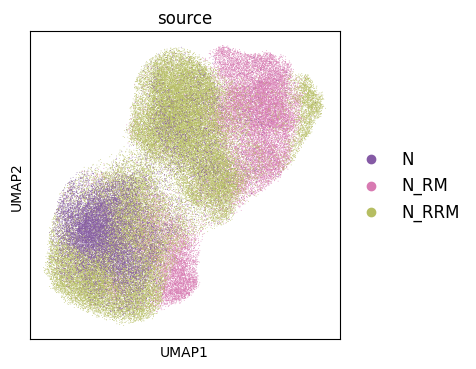

In [73]:
# UMAP highighting NBT sources
adata_normal.uns['source_colors'] = ['#855AA5', '#D87AB2', '#B6BE62']
fig, axes = plt.subplots(1, 1, figsize=(4, 4))
sc.pl.umap(adata_normal, color='source', legend_fontsize=12, show=False, ax=axes)
plt.savefig(f'{save_prefix}/umap/{groupby}_umap_source.png', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

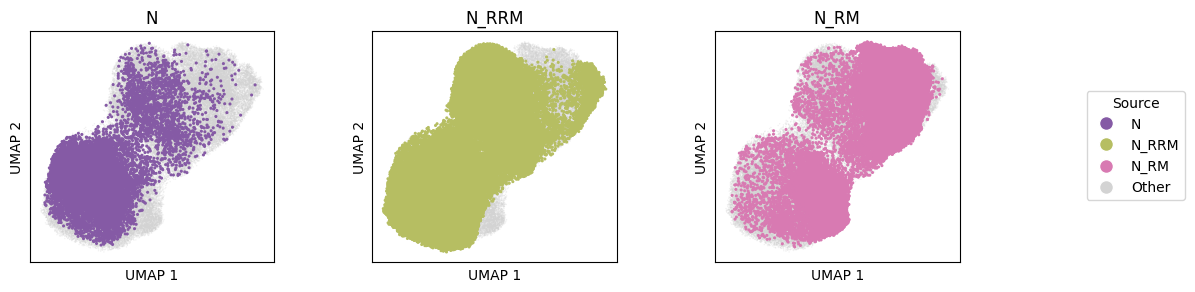

In [98]:
# UMAP highighting individual NBT source
orders = ['N', 'N_RRM', 'N_RM']
colors = {'N': '#855AA5', 'N_RM': '#D87AB2', 'N_RRM': '#B6BE62', 'other': 'gray'}
save_pt = f'{save_prefix}/umap/{groupby}_umap_source_separate.png'
plot_umap_highlight_each_category(adata_normal, category='source', orders=orders, colors=colors,
                                  max_size=5, min_size=1, fontsize=12,
                                  grid_size=(1, 3), figsize=(12, 3), save_pt=None)

In [ ]:
# UMAP highighting cohorts and individual WSI
adata_normal.obs['cohort'] = adata_normal.obs['cohort'].astype('category')
adata_normal.uns['cohort_colors'] = ['#1f77b4', '#ff7f0e']

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

sc.pl.umap(adata_normal, color="cohort", legend_fontsize=12, size=2, ax=axes[0], show=False)
axes[0].set_title('UMAP by Cohort', fontsize=10)
axes[0].set_xlabel("UMAP 1", fontsize=9)
axes[0].set_ylabel("UMAP 2", fontsize=9)

plot_umap_with_random_wsi(adata_normal, n_iterations=10, fontsize=8, ax=axes[1])
axes[1].set_title('UMAP with Random WSI Highlights', fontsize=9)
axes[1].set_xlabel("UMAP 1", fontsize=9)
axes[1].set_ylabel("UMAP 2", fontsize=9)

plt.tight_layout()
plt.savefig(f'{save_prefix}/umap/{groupby}_umap_cohort_wsi.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

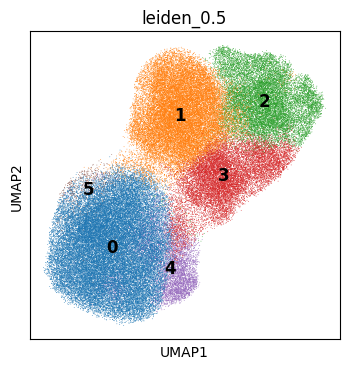

In [73]:
# UMAP visualisation of NBTs grouped as different clusters
fig, axes = plt.subplots(1, 1, figsize=(4, 4))
sc.pl.umap(adata_normal, color=groupby, legend_fontsize=12, legend_loc='on data', show=False, ax=axes)
plt.savefig(f'{save_prefix}/umap/{groupby}_umap_clusters.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.show()

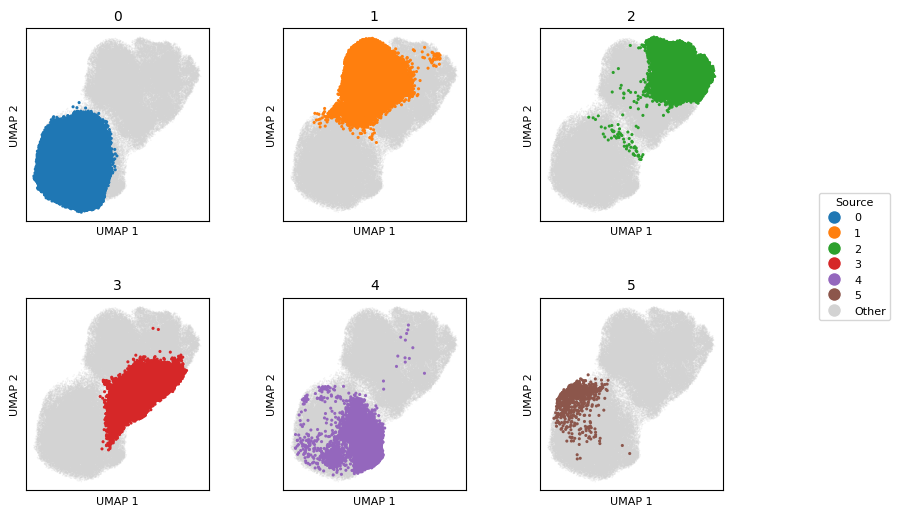

In [74]:
# Separate UMAP visualisation of NBTs grouped as different clusters
orders = ['0', '1', '2', '3', '4', '5']
colors = {'0': adata_normal.uns['leiden_0.5_colors'][0], 
          '1': adata_normal.uns['leiden_0.5_colors'][1],
          '2': adata_normal.uns['leiden_0.5_colors'][2],
          '3': adata_normal.uns['leiden_0.5_colors'][3], 
          '4': adata_normal.uns['leiden_0.5_colors'][4],
          '5': adata_normal.uns['leiden_0.5_colors'][5]}

save_pt = f'{save_prefix}/umap/{groupby}_umap_clusters_separate.pdf'
plot_umap_highlight_each_category(adata_normal, category=groupby, orders=orders, colors=colors, 
                                  max_size=5, min_size=1, fontsize=10,
                                  grid_size=(2, 3), figsize=(9, 6), save_pt=save_pt)

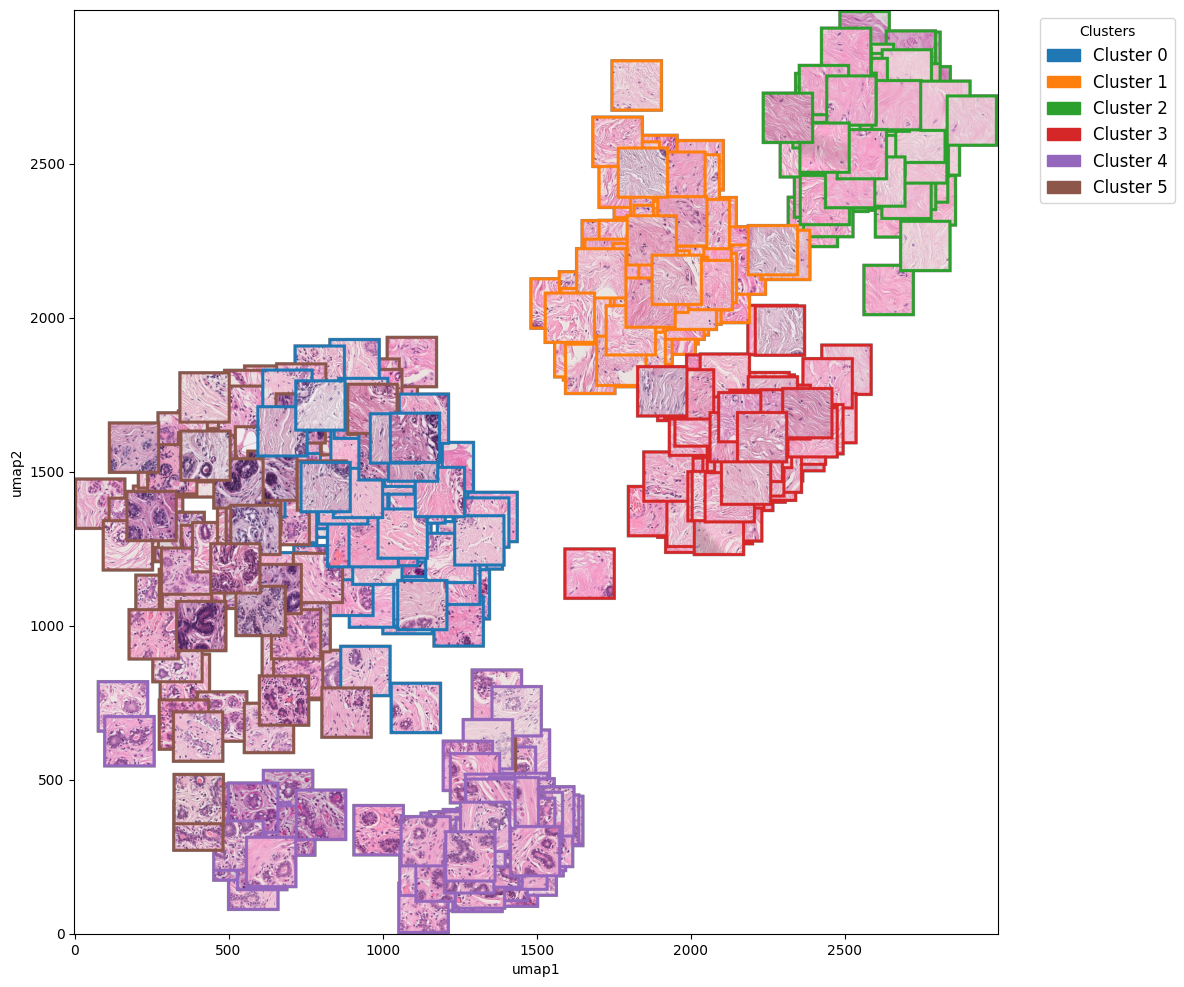

In [23]:
# Obtain top H&E patches of each cluster
adata_normal.obs.index = adata_normal.obs['patch_id']
adata_normal = calculate_top_samples(adata_normal, groupby, top_n=100)

# H&E overlay of the UMAP
save_pt = f'{save_prefix}/umap/{groupby}_umap_HEovrelay.pdf'
full_img = tsne_HE_overlay(adata_normal, groupby='leiden_0.5', image_size=(3000, 3000), max_dim=150, save_pt=save_pt)

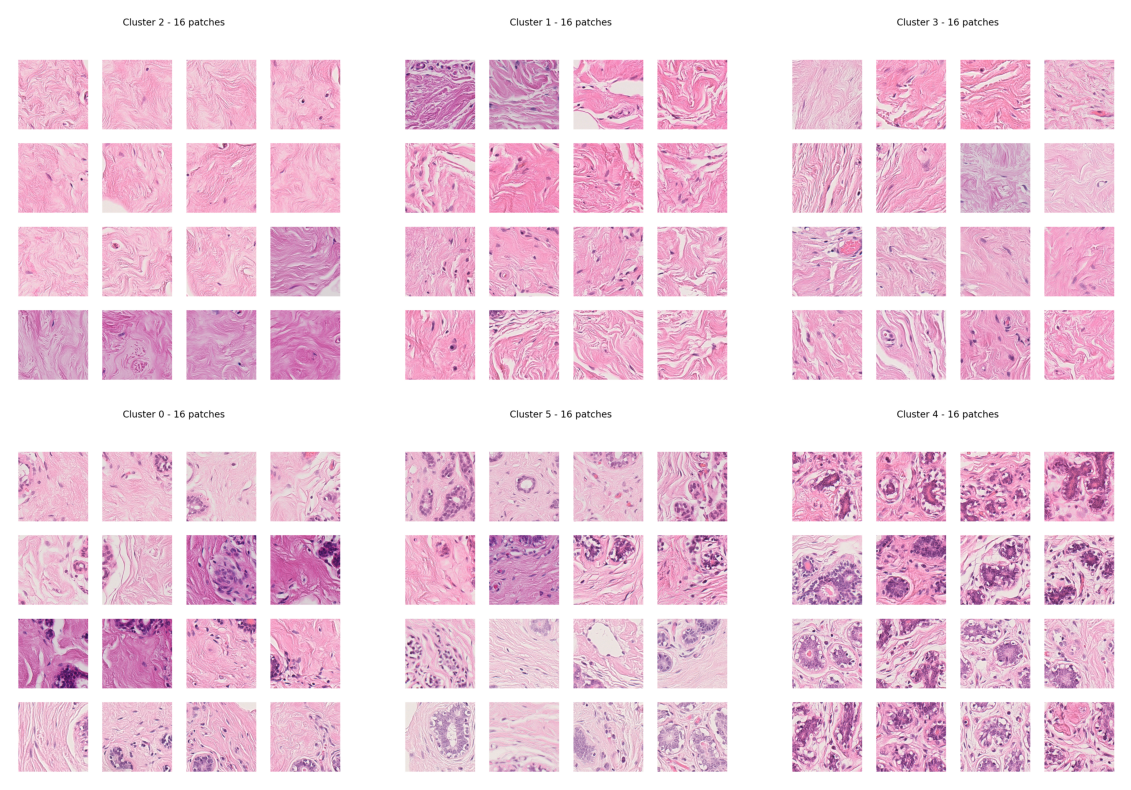

In [67]:
# Visualisation of the top H&E patches of each cluster
save_dir = f'{save_prefix}/{groupby}_patch_examples'
os.makedirs(save_dir, exist_ok=True)
for i, cluster_id in enumerate(np.unique(adata_normal.obs[groupby])):
    plot_cluster_examples(adata_normal, groupby, cluster_id, sampled_number=16, 
                          grid_size=[4, 4], figsize=(5, 5), fontsize=8, save_dir=save_dir, save_patches=False)
    

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for idx, cluster_id in enumerate([2,1,3,0,5,4]):
    row = idx // 3
    col = idx % 3
    img_path = os.path.join(save_dir, f"leiden_0.5_cluster{cluster_id}.png")
    img = Image.open(img_path)
    axes[row, col].imshow(img)
    axes[row, col].axis('off')


plt.tight_layout()
save_pt = f'{save_prefix}/cluster_examples/UNI_aug_{groupby}_cluster_examples.png'
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

# Leiden clustering at resolutions of 1.0, 1.5, 2.0

,patch_id,cohort,wsi_id,source,leiden_0.5,umap1,umap2,leiden_0.5_top_samples,leiden_1.0,leiden_1.5,leiden_2.0
patch_id,,,,,,,,,,,
17027148_FPE_2_12580_1986_92469_86893_99_91_555,17027148_FPE_2_12580_1986_92469_86893_99_91_555,KHP,17027148_FPE_2,N_RM,2,11.747646,6.762438,False,9,6,15
17027148_FPE_2_12580_1986_92469_86893_62_120_555,17027148_FPE_2_12580_1986_92469_86893_62_120_555,KHP,17027148_FPE_2,N_RM,3,11.986761,4.507391,False,9,6,13
17027148_FPE_2_12580_1986_92469_86893_104_90_555,17027148_FPE_2_12580_1986_92469_86893_104_90_555,KHP,17027148_FPE_2,N_RM,2,12.756907,8.744643,False,10,15,27
17027148_FPE_2_12580_1986_92469_86893_79_118_555,17027148_FPE_2_12580_1986_92469_86893_79_118_555,KHP,17027148_FPE_2,N_RM,3,11.095161,4.749600,False,9,6,13
17027148_FPE_2_12580_1986_92469_86893_150_148_555,17027148_FPE_2_12580_1986_92469_86893_150_148_555,KHP,17027148_FPE_2,N_RM,0,2.564113,2.191250,False,1,4,7
...,...,...,...,...,...,...,...,...,...,...,...
BRACS_773_N_33_768_0,BRACS_773_N_33_768_0,BRCAS,BRACS_773_N_33,N,1,3.437264,9.901889,False,0,14,28
BRACS_773_N_33_768_256,BRACS_773_N_33_768_256,BRCAS,BRACS_773_N_33,N,3,5.882754,1.325934,False,2,5,18
BRACS_773_N_33_1280_512,BRACS_773_N_33_1280_512,BRCAS,BRACS_773_N_33,N,0,2.701497,2.551752,False,4,4,24


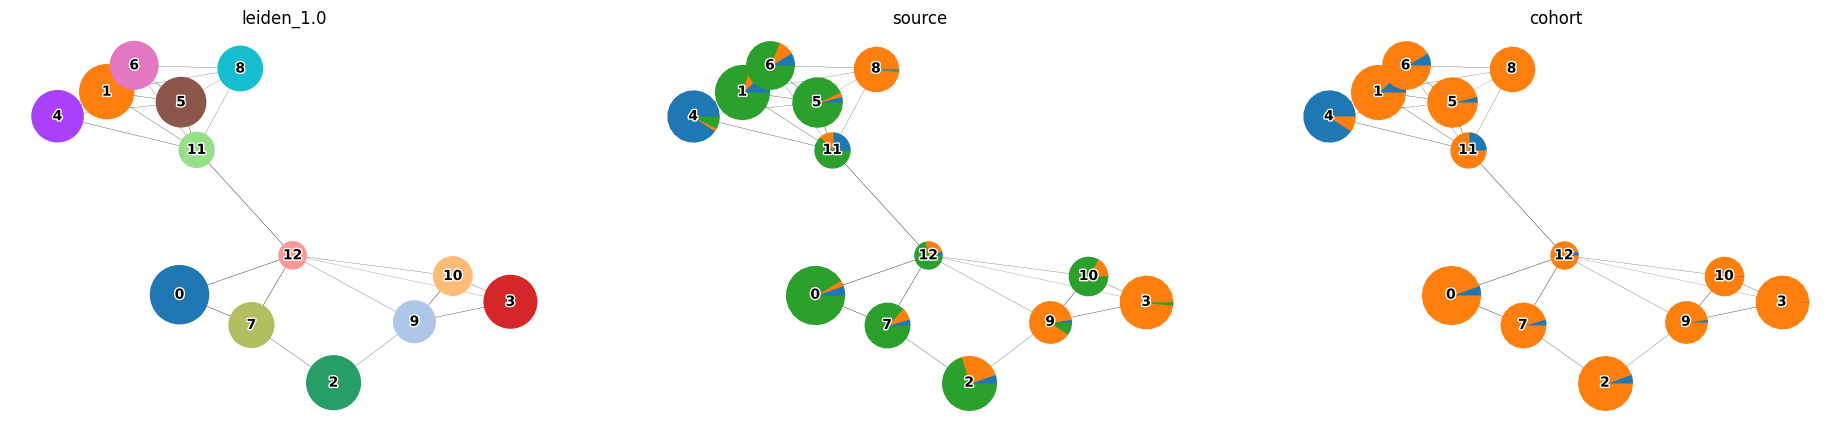

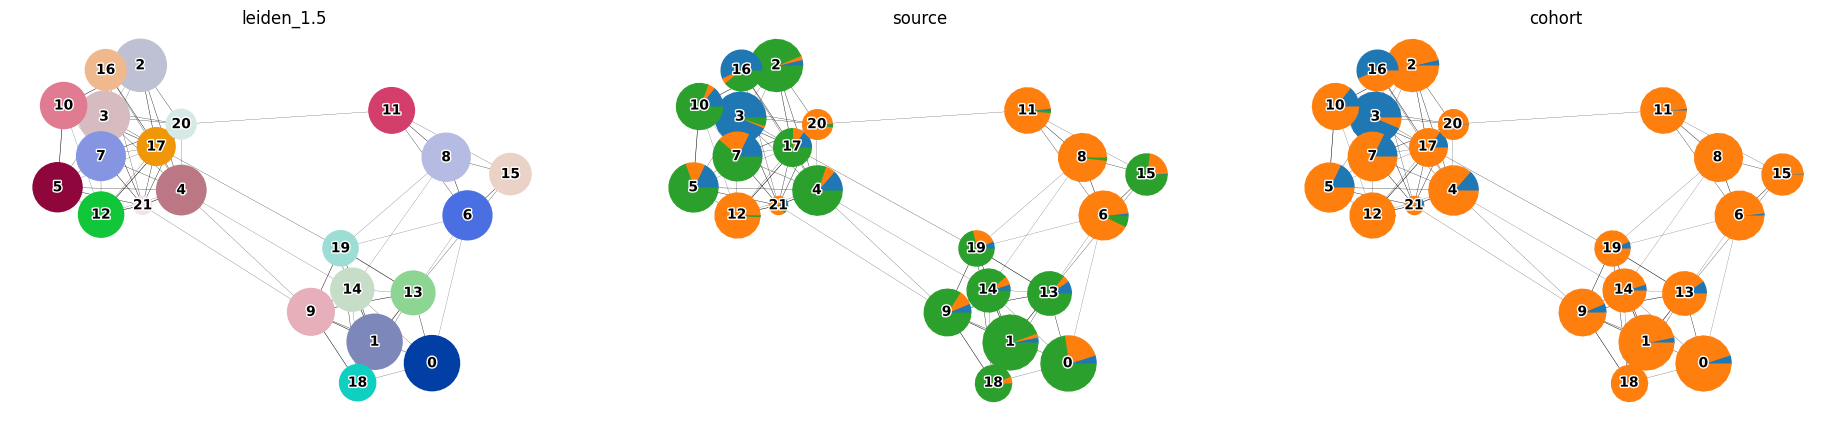

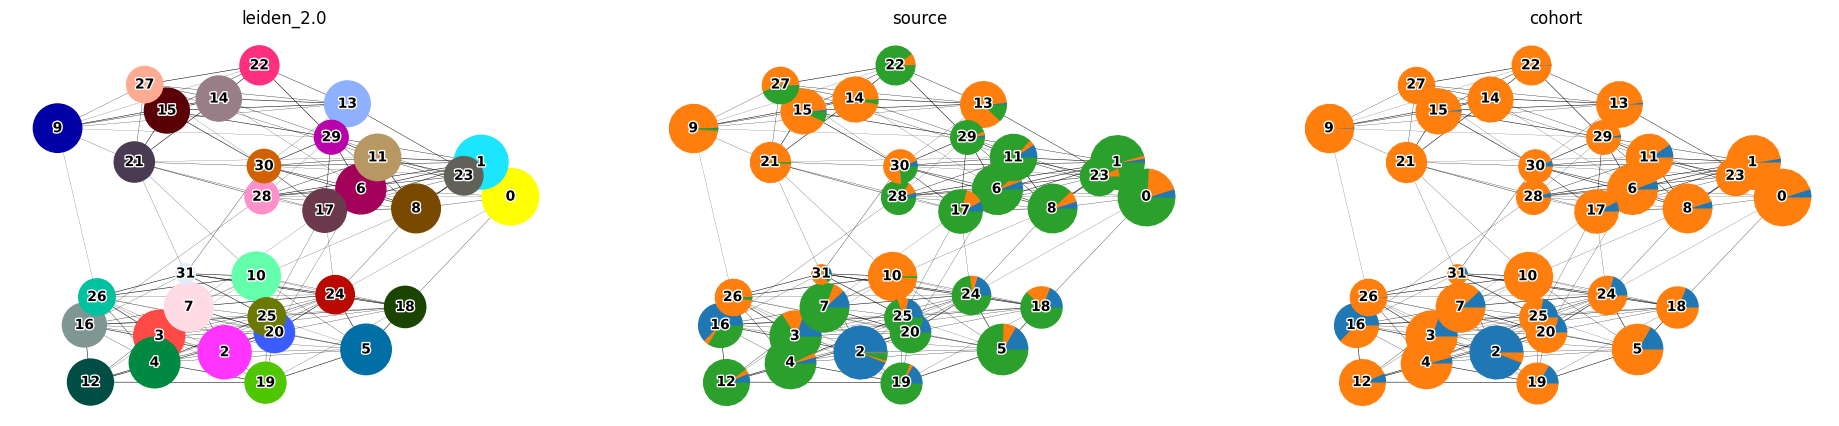

In [24]:
# run Leiden clustering at resolutions of 1.0, 1.5, 2.0
for resolution in [1.0, 1.5, 2.0]:
    adata_normal = run_leiden_umap(adata_normal, n_neighbors, resolution)

adata_normal.write(f'{save_prefix}/adata/adata_NBTs_4levels.h5ad')
adata_normal.obs

In [ ]:
# Visualisation of the top H&E patches of each cluster
groupby = 'leiden_1.0'
save_dir = f'{save_prefix}/UNI_aug_{groupby}_patch_examples'

os.makedirs(save_dir, exist_ok=True)
for i, cluster_id in enumerate(np.unique(adata.obs[groupby])):
    plot_cluster_examples(adata, groupby, cluster_id, sampled_number=16, 
                          grid_size=[4, 4], figsize=(5, 5), fontsize=8, save_dir=save_dir, save_patches=False)
    

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for idx, cluster_id in enumerate([2,1,3,0,5,4]):
    row = idx // 3
    col = idx % 3
    img_path = os.path.join(save_dir, f"leiden_0.5_cluster{cluster_id}.png")
    img = Image.open(img_path)
    axes[row, col].imshow(img)
    axes[row, col].axis('off')
    
plt.tight_layout()
save_pt = f'{save_prefix}/UNI_aug_{groupby}_patch_examples.png'
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [ ]:
# Visualisation of the top H&E patches of each cluster
groupby = 'leiden_1.5'
save_dir = f'{save_prefix}/UNI_aug_{groupby}_patch_examples'

os.makedirs(save_dir, exist_ok=True)
for i, cluster_id in enumerate(np.unique(adata.obs[groupby])):
    plot_cluster_examples(adata, groupby, cluster_id, sampled_number=16, 
                          grid_size=[4, 4], figsize=(5, 5), fontsize=8, save_dir=save_dir, save_patches=False)
    

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for idx, cluster_id in enumerate([2,1,3,0,5,4]):
    row = idx // 3
    col = idx % 3
    img_path = os.path.join(save_dir, f"leiden_0.5_cluster{cluster_id}.png")
    img = Image.open(img_path)
    axes[row, col].imshow(img)
    axes[row, col].axis('off')
    
plt.tight_layout()
save_pt = f'{save_prefix}/UNI_aug_{groupby}_patch_examples.png'
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [ ]:
groupby = 'leiden_2.0'
save_dir = f'{save_prefix}/patch_examples/UNI_aug_{groupby}_patch_examples'

os.makedirs(save_dir, exist_ok=True)
for i, cluster_id in enumerate(np.unique(adata.obs[groupby])):
    plot_cluster_examples(adata, groupby, cluster_id, sampled_number=16, 
                          grid_size=[4, 4], figsize=(5, 5), fontsize=8, save_dir=save_dir, save_patches=False)
    

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for idx, cluster_id in enumerate([2,1,3,0,5,4]):
    row = idx // 3
    col = idx % 3
    img_path = os.path.join(save_dir, f"leiden_0.5_cluster{cluster_id}.png")
    img = Image.open(img_path)
    axes[row, col].imshow(img)
    axes[row, col].axis('off')
    
plt.tight_layout()
save_pt = f'{save_prefix}/patch_examples/UNI_aug_{groupby}_cluster_examples.png'
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

# Clustree visualisation of parent-children relationships among clusters identified at different resolutions

In [8]:
import os
os.environ["R_HOME"] = "/scratch/users/k21066795/conda/miloR/lib/R"

import sys
sys.path.append('/scratch/users/k21066795/conda/miloR')
sys.path.append('/scratch/users/k21066795/NBT-phenotyping')

import anndata2ri
import rpy2.rinterface_lib.callbacks
import logging

rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

In [ ]:
anndata2ri.activate()

In [5]:
%load_ext rpy2.ipython

In [ ]:
%%R
library(clustree)
library(ggplot2)
options(scipen = 999)
library(scales)
library(tidyr)
library(pheatmap)

In [15]:
# load adata containing leiden clustering results
file_path = f'{basedir}/NBTs_phenotypes03/adata/adata_NBTs_4levels.h5ad'
adata_normal = sc.read_h5ad(file_path)

leiden_columns = [col for col in adata_normal.obs.columns if 'top_samples' not in col]
data = adata_normal.obs.loc[:, leiden_columns]
data.columns = data.columns.str.replace('.', '', regex=False)
leiden_columns = [col for col in data.columns if col.startswith('leiden_')]
data[leiden_columns] = data[leiden_columns].apply(pd.to_numeric, errors='coerce')

In [12]:
%%R -i data
colnames(data)

 [1] "patient_id" "age"        "patch_id"   "cohort"     "wsi_id"    
 [6] "source"     "leiden_05"  "umap1"      "umap2"      "leiden_10" 
[11] "leiden_15"  "leiden_20"  "risk"      


Scale for edge_colour is already present.
Adding another scale for edge_colour, which will replace the existing scale.


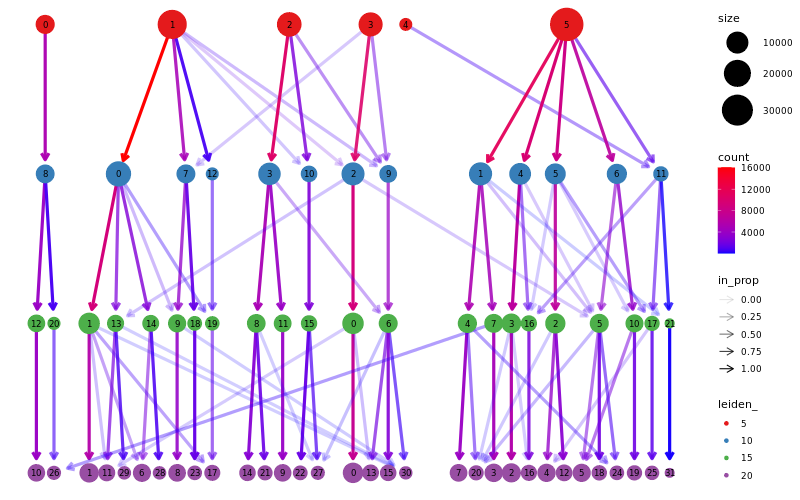

In [117]:
%%R -w 800 -h 500
data <- data.frame(
    leiden_05 = data$leiden_05,
    leiden_10 = data$leiden_10,
    leiden_15 = data$leiden_15,
    leiden_20 = data$leiden_20
)
p <- clustree(data, prefix = "leiden_") +
  scale_color_brewer(palette = "Set1") +
  scale_edge_color_continuous(low = "blue", high = "red")

ggsave(f"{save_prefix}/Clustree/NBTs_clustree_4levels.pdf", plot = p, width = 8, height = 5, device = "pdf")
p